In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('insurance.csv')

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,SGDRegressor

In [6]:
data.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [7]:
data.shape

(1338, 7)

In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
data=pd.get_dummies(data,drop_first=True)
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


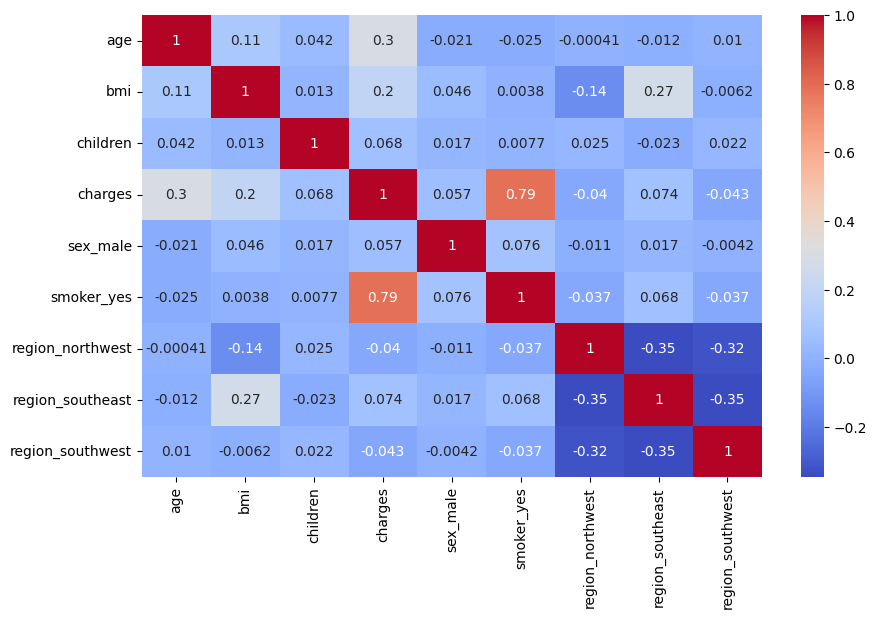

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(),cmap='coolwarm',annot=True)
plt.show()


[]

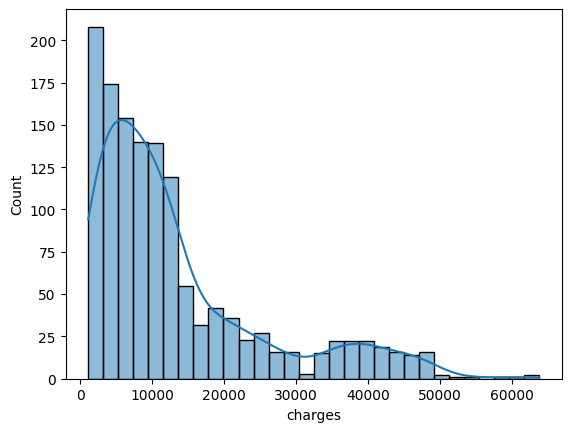

In [13]:
sns.histplot(data['charges'],kde='True')
plt.plot()

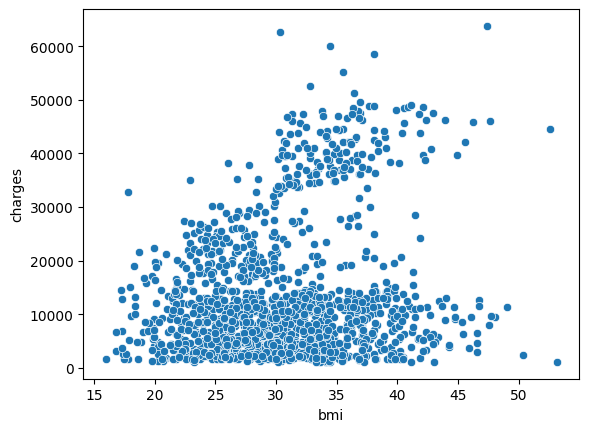

In [18]:
sns.scatterplot(x=data["bmi"],y=data["charges"])
plt.show()

In [20]:
x=data.drop("charges",axis=1)
y=data['charges']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [25]:
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_pred=lr.predict(x_test_scaled)
print("r2_score:",r2_score(y_test,y_pred))
print("mse:",mean_squared_error(y_test,y_pred))

r2_score: 0.7835929767120722
mse: 33596915.85136149


In [27]:
poly=PolynomialFeatures(degree=2)
x_train_scaled=poly.fit_transform(x_train)
x_test_scaled=poly.transform(x_test)
model_poly=LinearRegression()
model_poly.fit(x_train_scaled,y_train)

y_pred_poly=model_poly.predict(x_test_scaled)
print("polynomial r2:",r2_score(y_test,y_pred_poly))

polynomial r2: 0.8665830903164841


In [28]:
sgd=SGDRegressor(max_iter=100,learning_rate="invscaling")
sgd.fit(x_train_scaled,y_train)
y_pred_sgd=sgd.predict(x_test_scaled)
print("SGD R2:",r2_score(y_test,y_pred_sgd))

SGD R2: -1.6553607975590156e+23


In [29]:
pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("poly",PolynomialFeatures(degree=2)),
    ("model",LinearRegression())
])
pipeline.fit(x_train,y_train)
pred_pipeline=pipeline.predict(x_test)
print("pipelie r2:",r2_score(y_test,pred_pipeline))

pipelie r2: 0.866583090316484


In [30]:
sample=x_test.iloc[0:1]
prediction=pipeline.predict(sample)
print("predicted insurance cost",prediction)

predicted insurance cost [11215.72133573]
